# Bacterial Population Control

In this example, we apply AutoReduce to a biological circuit that implements population control in a bacterial consortium. Two cell types mutually repress each other's growth by activating toxin production in the opposite cell type. The detailed model has 8 states, and the goal is to derive and inspect a lower-dimensional model that preserves the population-level behavior.

This system model and the resulting reduced models were applied in practice to design a synthetic bacterial consortium that can maintain a stable population ratio between two cell types. Read more [here](https://www.biorxiv.org/content/10.1101/632174v1.abstract): McCardell, Reed D., Ayush Pandey, and Richard M. Murray. "Control of density and composition in an engineered two-member bacterial community." BioRxiv (2019): 632174.


## Model description

In other example notebooks, we import models written in the standard biological modeling language, the Systems Biology Markup Language (SBML). To demonstrate the versatility of AutoReduce, we define the ODE model directly in Python here and use `load_ode_model` to create the symbolic state and parameter containers needed by AutoReduce.


In [1]:
from autoreduce import System, load_ode_model
import numpy as np
from sympy import symbols

In [2]:
n = 8 # Number of states
x_init = np.zeros(n)
# initial population of cell 1 and cell 2
x_init[6] = 100
x_init[7] = 500

timepoints_ode = np.linspace(0, 40, 100) # timepoints for ODE simulation

# define tolerance levels for the error and
# for minimum number of states required for the reduced model

error_tol = 1000
nstates_tol = 5


## Define all symbols

The model has 8 state variables: toxin and antitoxin species for each cell type, two signal species, and the two cell populations. The numerical parameter values come from the population-control model in the cited work, while the symbolic parameter names are used by AutoReduce for sensitivity analysis and symbolic reduction.


In [3]:
# the parameter values below come from the literature (see paper cited above)
#      x = 0, T1, 1, A1, 2, S1, 3, S2, 4, T2, 5, A2, 6, C1, 7, C2
#      P = 0, beta_S1, 1, l_S1, 2, K_S1, 3, kb, 4, beta_S2, 5, l_S2, 6,
#      K_S2, 7, beta_lac, 8, l_lac, 9, K_lac, 10, beta_tet, 11, l_tet, 12,
#      K_tet, 13, kc, 14, C_max, 15, dc, 16, 17, I, 18, atc, 20,K_tox

P = np.zeros(22)
P = [
    6, 2e-3, 430, 30, 6, 2e-3, 190, 19.8e-3, 1.5e-3, 1.4e5,
    14.4e-3, 2.1e-4, 13, 0.6, 5500, 0.8, 1e6,
    324, 1, 0.1, 1.5, 0.5
]

params_values = P.copy()

params = P

n = 8

x, f, P = load_ode_model(n, len(params_values))

beta_S1, l_S1, K_S1 = symbols('beta_S1, l_S1, K_S1')
kb, beta_S2, l_S2, K_S2 = symbols('kb, beta_S2, l_S2, K_S2')
beta_lac, l_lac, K_lac = symbols('beta_lac, l_lac, K_lac')
beta_tet, l_tet, K_tet = symbols('beta_tet, l_tet, K_tet')
kc, C_max, dc = symbols('kc, C_max, dc')
I, atc, K_tox = symbols('I, atc, K_tox')
d, d_T, d_S = symbols('d, d_T, d_S')
y0, y1 = symbols('y0, y1')

P = [beta_S1, l_S1, K_S1, kb, beta_S2, l_S2, K_S2, beta_lac, l_lac,
    K_lac, beta_tet, l_tet, K_tet, kc, C_max, dc, I,
    atc, K_tox, d, d_T, d_S]

## Define the ODE model

The first six equations describe gene-expression and toxin-antitoxin dynamics. The last two equations describe logistic growth of the two cell populations, with toxin-mediated growth inhibition coupling the intracellular circuit to population dynamics.


In [4]:
# T1 and A1
f[0] = P[0]*(P[1] + x[2]**2/(P[2]+x[2]**2)) - P[3]*x[0]*x[1] - P[20] * x[0]
f[1] = 5*P[4]*(P[5] + x[3]**2/(P[6]+x[3]**2)) - P[20] * x[1] - P[3]*x[0]*x[1]


#  S1 and S2 (scaled with cell count)
f[2] = P[7]*(P[8] + P[16]**2/(P[9]+P[16]**2))*x[6] - P[21] * x[2]
f[3] = P[10]*(P[11] + P[17]**2/(P[12]+P[17]**2))*x[7] - P[21] * x[3]

#  T2 and A2
f[4] = P[4]*(P[5] + x[3]**2/(P[6]+x[3]**2)) - P[3]*x[4]*x[5] - P[20] * x[4]
f[5] = 5*P[0]*(P[1] + x[2]**2/(P[2]+x[2]**2)) - P[20] * x[5]-P[3]*x[4]*x[5]

#  Cell 1 and Cell 2
f[6] = P[13]*(1 - (x[6] + x[7])/P[14])*x[6] - P[15]*x[6]*(x[0]/(P[18] + x[0])) - P[19] * x[6]
f[7] = P[13]*(1 - (x[6] + x[7])/P[14])*x[7] - P[15]*x[7]*(x[4]/(P[18] + x[4])) - P[19] * x[7]


## Declare outputs using the C matrix

The output matrix selects the two population states, `C1` and `C2`. These are the quantities we want the reduced model to match because the biological design objective is about population density and composition.


In [5]:
C = np.zeros((2,len(x)), dtype=int)
C[0][6] = 1
C[1][7] = 1
C = C.tolist()

## Create a System

The `System` object stores the state equations, parameter values, outputs, and initial condition in the format used by the solvers and reduction routines.


In [6]:
sys = System(x, f, params = P, params_values = params_values, C = C, x_init = x_init)

## Solve the full system using AutoReduce solvers

Before reducing the model, we simulate the full 8-state system. This gives a baseline trajectory for the two population outputs.


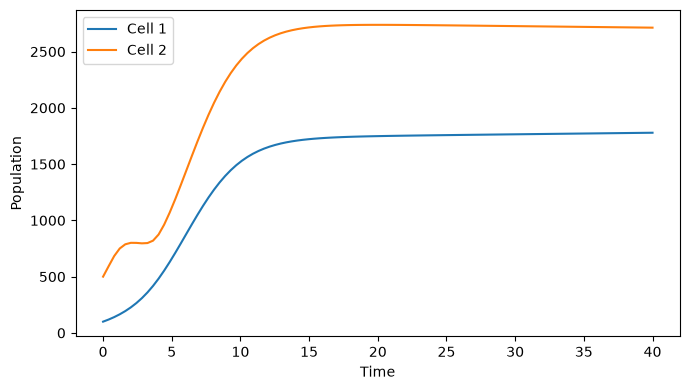

In [7]:
from autoreduce import solve_ode

try:
    import matplotlib.pyplot as plt

    full_solution = solve_ode(sys, timepoints_ode).T
    full_outputs = np.asarray(C) @ full_solution

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(timepoints_ode, full_outputs[0], label='Cell 1')
    ax.plot(timepoints_ode, full_outputs[1], label='Cell 2')
    ax.set_xlabel('Time')
    ax.set_ylabel('Population')
    ax.legend()
    fig.tight_layout()
    plt.show()
except ImportError:
    print('Plotting libraries missing.')


## Optional sensitivity analysis

The sensitivity solver can be run directly on the `System`. For this larger model, the time grid is kept short so the example remains lightweight when rerun. The heatmaps below show how each population output changes with respect to the model parameters over the selected time points.


In [8]:
from autoreduce import solve_sensitivity
timepoints_ssm = np.linspace(0,100,5)
Ss = solve_sensitivity(sys, timepoints_ssm)
print(Ss.shape)  # Should be (5, 10, 8) - len(timepoints) x len(params) x len(states)

(5, 22, 8)


C:\Users\ayush\Box\Research\autoReduce_HPC\autoreduce\solvers\utils.py:114: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = odeint(extended_rhs, y0, timepoints, tfirst=True, **kwargs)


In [9]:
nouts = 2
out_Ss = []
for i in range(len(params)):
    out_Ss.append((np.array(C)@(Ss[:,i,:].T)))
out_Ss = np.reshape(np.array(out_Ss), (len(timepoints_ssm), len(params), nouts))

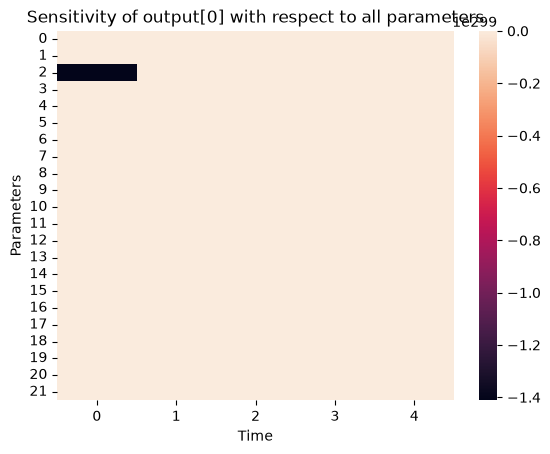

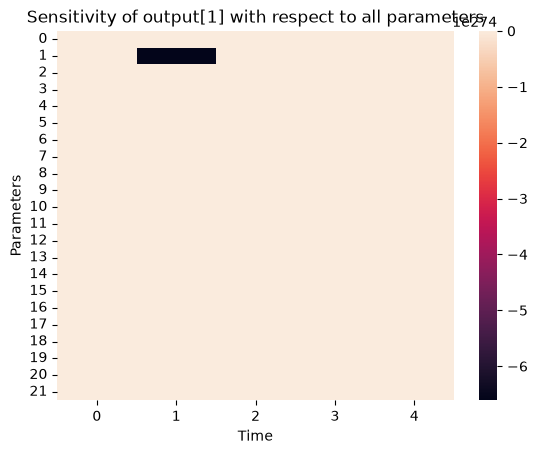

In [10]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

## Explore reduced models

Using `explore_all_QSS_models`, we can scan for QSS reductions without manually creating an intermediate reducible object. Here we skip numerical error and robustness calculations during the scan so the notebook can quickly list symbolic candidate reductions. After the scan, we choose one biologically meaningful four-state model and inspect it in more detail.


In [ ]:
from autoreduce import explore_all_QSS_models

reduction_timepoints_ode = np.linspace(0, 24, 25)
reduction_timepoints_ssm = np.linspace(0, 24, 2)

results = explore_all_QSS_models(
    sys,
    timepoints_ode=reduction_timepoints_ode,
    timepoints_ssm=reduction_timepoints_ssm,
    nstates_tol=7,
    nstates_tol_min=6,
    skip_numerical_computations=True,
    debug=False,
)

print(f'Found {len(results)} candidate reduced models.')


## Choose a reduced model

For the detailed comparison, we retain the two antitoxin states and the two population states. The toxin and signal states are treated as fast variables and collapsed using the QSS equations produced by `solve_timescale_separation`.


In [ ]:
from autoreduce import solve_timescale_separation

retained_states = [x[1], x[5], x[6], x[7]]
reduced_sys_1567, collapsed_sys_1567 = solve_timescale_separation(
    sys,
    retained_states,
    timepoints_ode=reduction_timepoints_ode,
    timepoints_ssm=reduction_timepoints_ssm,
    skip_numerical_computations=True,
)

Successful solution obtained with states: [x1, x5, x6, x7]!


## Compare the reduced model with the full model

The comparison below focuses on the total population, `C1 + C2`. Plotting a single reduced model keeps the visual check tied to the model we selected, rather than mixing many candidate reductions in the same figure.


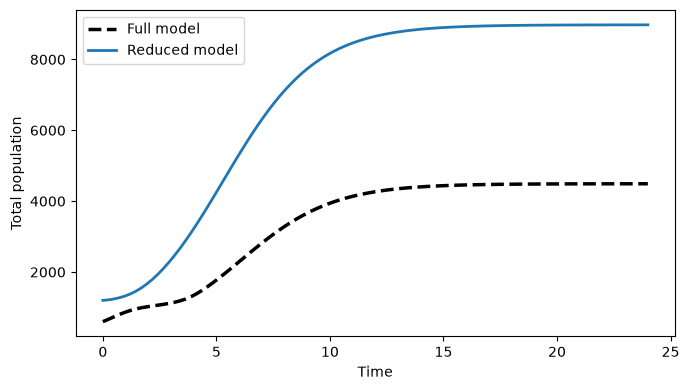

In [ ]:
from autoreduce import solve_ode

try:
    import matplotlib.pyplot as plt

    comparison_timepoints = np.linspace(0, 24, 100)
    full_solution = solve_ode(sys, comparison_timepoints).T
    reduced_solution = solve_ode(reduced_sys_1567, comparison_timepoints).T

    full_total_population = (np.asarray(sys.C) @ full_solution).sum(axis=0)
    reduced_total_population = (
        np.asarray(reduced_sys_1567.C) @ reduced_solution
    ).sum(axis=0)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        comparison_timepoints,
        full_total_population,
        'k--',
        linewidth=2.5,
        label='Full model',
    )
    ax.plot(
        comparison_timepoints,
        reduced_total_population,
        linewidth=2,
        label='Reduced model',
    )
    ax.set_xlabel('Time')
    ax.set_ylabel('Total population')
    ax.legend()
    fig.tight_layout()
    fig.savefig('pop_control_reduced_model_comparison.svg', bbox_inches='tight')
    plt.show()
except ImportError:
    print('Plotting libraries missing.')


## Plot one robustness metric

Finally, we compute the robustness metric for the same selected reduced model. The heatmap has one row because we are comparing one reduced model against the full system; each column is the contribution from one model parameter.


C:\Users\ayush\Box\Research\autoReduce_HPC\autoreduce\solvers\ode.py:64: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(


SSM Progress: |##################################################| 100.0% Complete
SSM Progress: |##################################################| 100.0% Complete


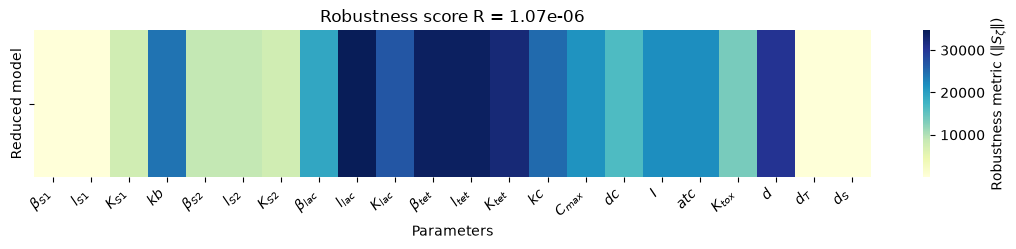

In [ ]:
from autoreduce import get_robustness_metric
from sympy import latex

try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    robustness_timepoints = np.linspace(0, 24, 2)
    Se_1567, R_1567 = get_robustness_metric(
        sys,
        reduced_sys_1567,
        timepoints_ode=comparison_timepoints,
        timepoints_ssm=robustness_timepoints,
    )

    parameter_labels = [f'${latex(parameter)}$' for parameter in P]

    fig, ax = plt.subplots(figsize=(11, 2.6))
    sns.heatmap(
        np.asarray([Se_1567]),
        ax=ax,
        cmap='YlGnBu',
        xticklabels=parameter_labels,
        yticklabels=['Reduced model'],
        cbar_kws={'label': r'Robustness metric ($\|S_\zeta\|$)'},
    )
    ax.set_xlabel('Parameters')
    ax.set_ylabel('')
    ax.set_title(f'Robustness score R = {R_1567:.3g}')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    fig.savefig('pop_control_robustness.svg', bbox_inches='tight')
    plt.show()
except ImportError:
    print('Plotting libraries missing.')
